# Fruit Freshness Inspection System


### **This project can be practically applied with some advancment in fruit sorting, grading, and quality control processes atpacking houses, wholesale markets, and supermarkets. The system can analyze fruit imagesand automatically flag rotten fruits, enabling faster and more consistent quality inspection.**

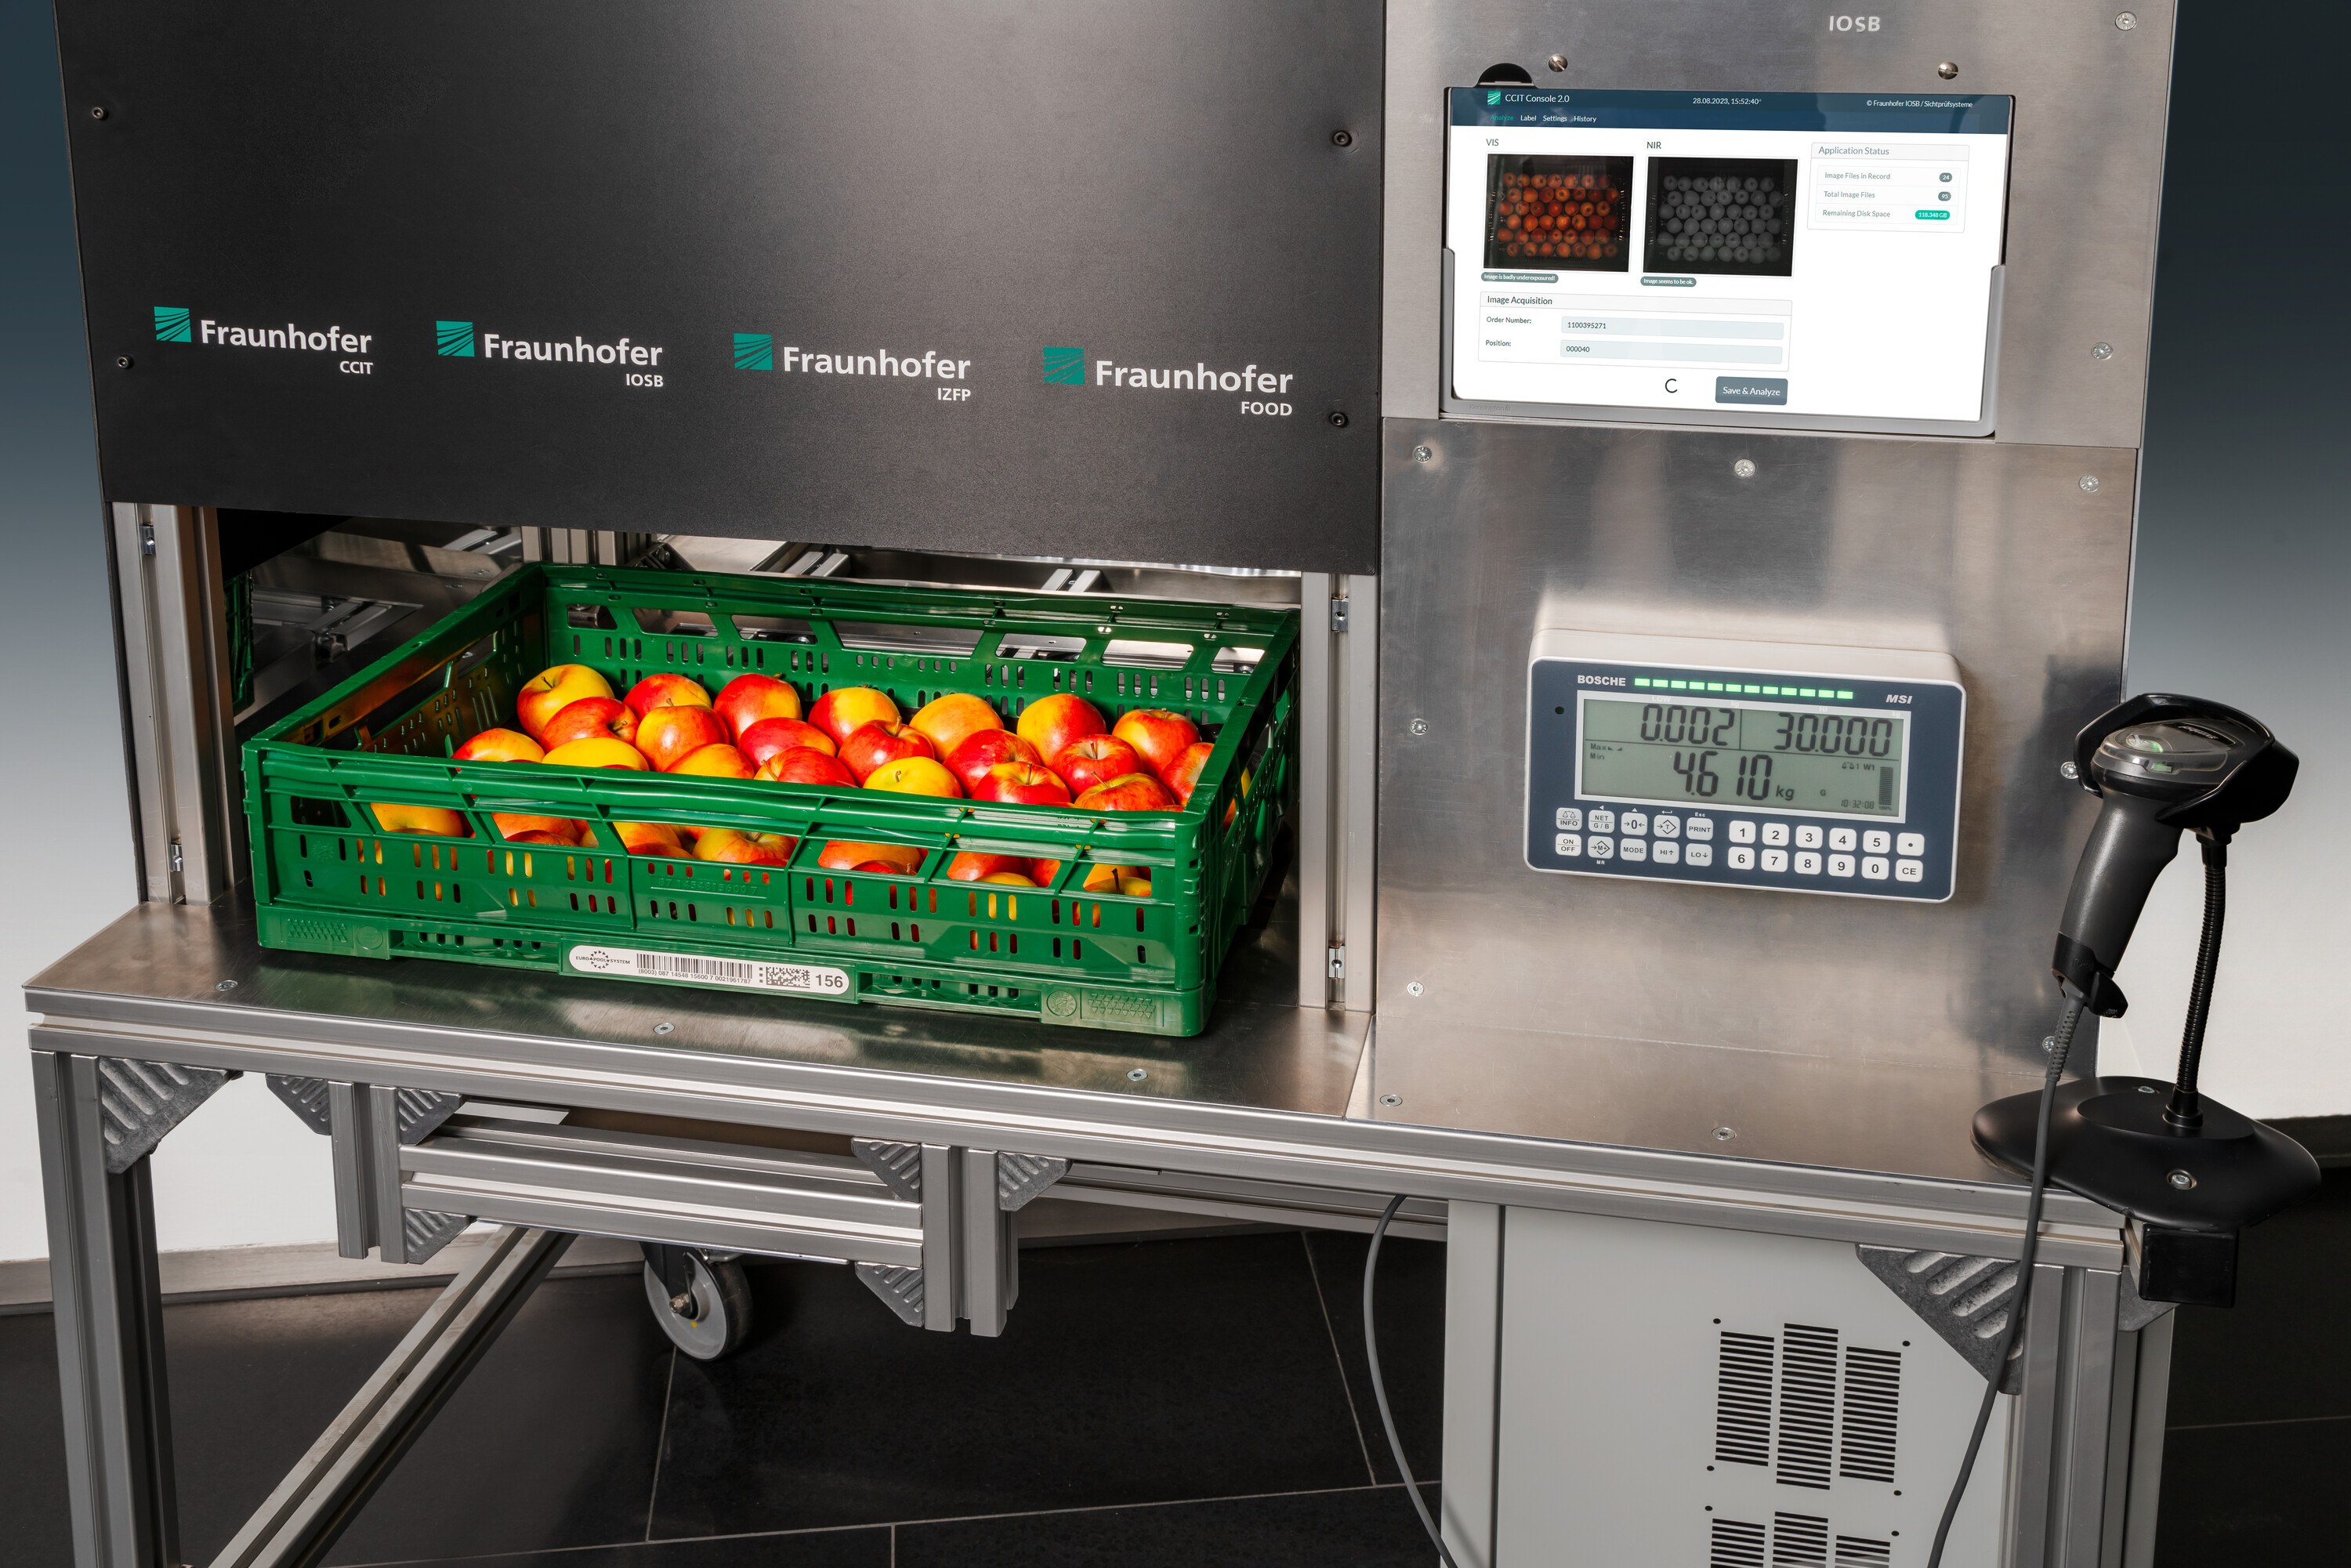

## Data Preparations

In [26]:
import pandas as pd
import numpy as np
import os, warnings
from matplotlib import gridspec
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory

# Reproducability 
def set_seed(seed=312):
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed()

# Set matplotlib defaults
plt.rc('figure',autolayout=True)
plt.rc('axes',labelweight='bold',labelsize='large', titleweight='bold', titlesize=18,titlepad=10)
plt.rc('image', cmap='magma')
warnings.filterwarnings('ignore')

target_classes =['Apple_Bad', 'Apple_Good','Banana_Bad',"Banana_Good","Guava_Bad","Guava_Good"]

#Using this method when we concatenate them it loss the class labels so I rearranged the images into one folder
# bad_dir = "/kaggle/input/datasets/shashwatwork/fruitnet-indian-fruits-dataset-with-quality/Processed Images_Fruits/Bad Quality_Fruits"
# good_dir = "/kaggle/input/datasets/shashwatwork/fruitnet-indian-fruits-dataset-with-quality/Processed Images_Fruits/Bad Quality_Fruits"


img_dir ="/kaggle/input/datasets/raqeeb24/5-fruit-types-good-bad/Good Quality_Fruits"

# ds_bad = image_dataset_from_directory(
#     bad_dir, label_mode='categorical',image_size=[128,128], batch_size=64
# ) # Assign label 0 to all "Bad" fruits

# ds_good = image_dataset_from_directory(
#     img_dir, label_mode='categorical',image_size=[128,128], batch_size=64
# ) # Assign label 1 to all "Good" fruits


ds_full = image_dataset_from_directory(
    img_dir, label_mode='categorical',class_names=target_classes,image_size=[256,256], batch_size=32
) 




Found 11325 files belonging to 10 classes.


In [27]:

print(ds_full.class_names)

['Apple_Bad', 'Apple_Good', 'Banana_Bad', 'Banana_Good', 'Guava_Bad', 'Guava_Good', 'Lime_Bad', 'Lime_Good', 'Orange_Bad', 'Orange_Good']


In [29]:
num_classes = len(ds_full.class_names) 
class_names = ds_full.class_names
print(f"Number of classes detected: {num_classes}")
print(f"Class names: {class_names} ",ds_full.class_names)

# 80% for training and 20% for validation from the training data
total_batches = len(ds_full)
train_size = int(0.8 * total_batches) 
val_size = total_batches - train_size
# Use a buffer size that is at least as large as your total number of batches
ds_full = ds_full.shuffle(buffer_size=len(ds_full), seed=312, reshuffle_each_iteration=False)

ds_train_ = ds_full.take(train_size)
ds_valid_ = ds_full.skip(train_size)



Number of classes detected: 10
Class names: ['Apple_Bad', 'Apple_Good', 'Banana_Bad', 'Banana_Good', 'Guava_Bad', 'Guava_Good', 'Lime_Bad', 'Lime_Good', 'Orange_Bad', 'Orange_Good']  ['Apple_Bad', 'Apple_Good', 'Banana_Bad', 'Banana_Good', 'Guava_Bad', 'Guava_Good', 'Lime_Bad', 'Lime_Good', 'Orange_Bad', 'Orange_Good']


## Scaling Image Pixcels

In [30]:


def convert_to_float(image, label):
    image = image / 255.0 
    return image, label
AUTOTUNE = tf.data.experimental.AUTOTUNE

ds_train = (
    ds_train_
    .map(convert_to_float)
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)

ds_valid = (
    ds_valid_
    .map(convert_to_float)
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)
for images, labels in ds_train.take(1):
    print("Max pixel value:", np.max(images[0]))
    print("Min pixel value:", np.min(images[0]))
    print("Shape of one image:", images[0].shape)
    print("Data type:", images.dtype)

Max pixel value: 1.0
Min pixel value: 0.0
Shape of one image: (256, 256, 3)
Data type: <dtype: 'float32'>


In [31]:
from keras.layers import Conv2D, Dense, MaxPooling2D, Flatten, Dropout, BatchNormalization
from keras import Sequential, layers

## Model Architecture 

In [ ]:


model = Sequential([
    layers.Input(shape=(256,256,3)),
     layers.RandomFlip('horizontal_and_vertical'),
    layers.RandomRotation(factor=0.5),
    layers.RandomZoom(height_factor=0.5, width_factor=0.5),
    layers.RandomHue(factor=0.1),
    layers.RandomTranslation(height_factor=0.1, width_factor=0.1)
])

# Convolutional Layers
model.add(
    Conv2D(16, kernel_size=(3,3),padding='valid', activation='relu')
)
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(
    Conv2D(32, kernel_size=(3,3),padding='valid', activation='relu')
)

model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(
    Conv2D(64, kernel_size=(3,3),padding='valid', activation='relu')
)

model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))


model.add(
    Conv2D(128, kernel_size=(3,3),padding='valid', activation='relu')
)

model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))


#Flatten 
model.add(
    Flatten()
)
#dense layers
model.add(
    Dense(128,activation='relu')
)
model.add(Dropout(0.1))
model.add(
    Dense(64,activation='relu')
)
model.add(Dropout(0.1))
model.add(
    Dense(32,activation='relu')
)

model.add(Dropout(0.1))
model.add(
    Dense(num_classes, activation='softmax')
)


## Model Training

In [33]:

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import optimizers
custom_optimizer = optimizers.Adam(learning_rate=0.0001)

model.compile(
    optimizer=custom_optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,          # Number of epochs to wait before stopping
    restore_best_weights=True
)

history = model.fit(
    ds_train,
    validation_data=ds_valid,
    epochs=100,
    verbose=1,
    # callbacks=[early_stopping] 
)

Epoch 1/100
283/283 ━━━━━━━━━━━━━━━━━━━━ 24s 68ms/step - accuracy: 0.2987 - loss: 2.0437 - val_accuracy: 0.2364 - val_loss: 2.1523
Epoch 2/100
283/283 ━━━━━━━━━━━━━━━━━━━━ 19s 67ms/step - accuracy: 0.5622 - loss: 1.3272 - val_accuracy: 0.7077 - val_loss: 0.9178
Epoch 3/100
283/283 ━━━━━━━━━━━━━━━━━━━━ 19s 67ms/step - accuracy: 0.6479 - loss: 1.1034 - val_accuracy: 0.7821 - val_loss: 0.7236
Epoch 4/100
283/283 ━━━━━━━━━━━━━━━━━━━━ 19s 67ms/step - accuracy: 0.6816 - loss: 0.9764 - val_accuracy: 0.7901 - val_loss: 0.6411
Epoch 5/100
283/283 ━━━━━━━━━━━━━━━━━━━━ 19s 67ms/step - accuracy: 0.7096 - loss: 0.9192 - val_accuracy: 0.7962 - val_loss: 0.6379
Epoch 6/100
283/283 ━━━━━━━━━━━━━━━━━━━━ 19s 67ms/step - accuracy: 0.7343 - loss: 0.8203 - val_accuracy: 0.8147 - val_loss: 0.5789
Epoch 7/100
283/283 ━━━━━━━━━━━━━━━━━━━━ 19s 67ms/step - accuracy: 0.7488 - loss: 0.7707 - val_accuracy: 0.8600 - val_loss: 0.4229
Epoch 8/100
283/283 ━━━━━━━━━━━━━━━━━━━━ 19s 67ms/step - accuracy: 0.7686 - loss: 0

## Visualiztion Of results

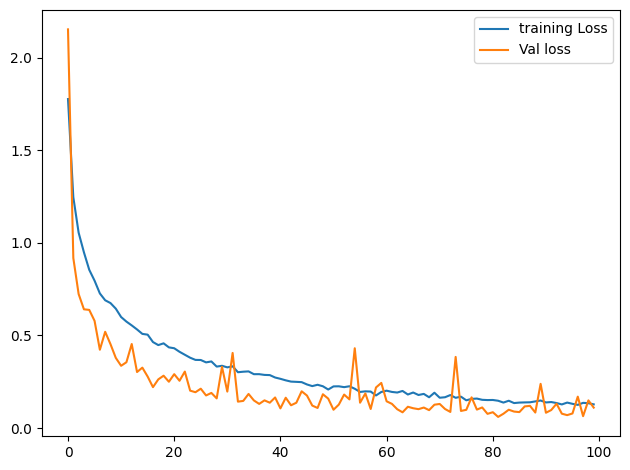

In [34]:
plt.plot(history.history['loss'],label='training Loss')
plt.plot(history.history['val_loss'],label='Val loss')
plt.legend()
plt.show()

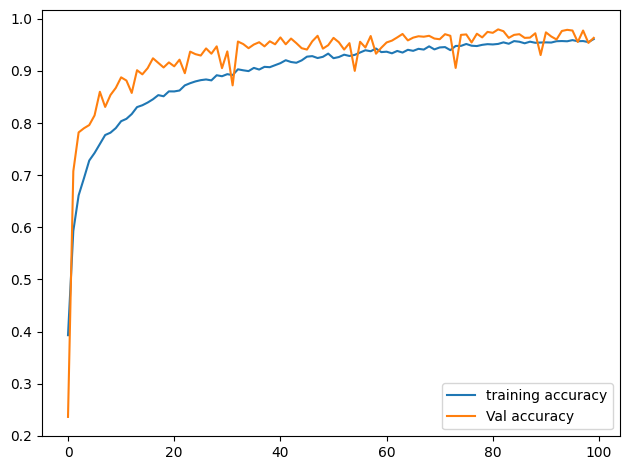

In [35]:
plt.plot(history.history['accuracy'],label='training accuracy')
plt.plot(history.history['val_accuracy'],label='Val accuracy')
plt.legend()
plt.show()

In [36]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

y_true = np.concatenate([y for x,y in ds_valid], axis =0)
y_true = np.argmax(y_true,axis=1)

y_pred_probs = model.predict(ds_valid)
y_pred = np.argmax(y_pred_probs, axis=1)

71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


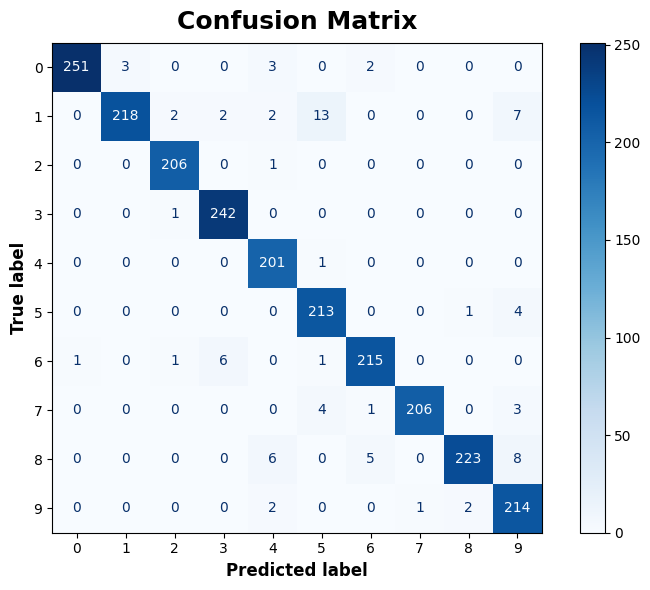

In [38]:
cn = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cn)
fig, ax = plt.subplots(figsize=(8,6))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title("Confusion Matrix")
plt.show()

## Saving Model

In [39]:

model.save('Fruit_freshness_10_classes.keras')

## Simple Testing

In [44]:
from keras.utils import load_img, img_to_array


img = load_img("/kaggle/input/datasets/raqeeb24/fruit-test/apple.jpeg", target_size=(256, 256))


#Convert to numpy array
img_array = img_to_array(img)

#normalize (Must match training normalization, e.g., /255.0)
img_array = img_array / 255.0

img_array = np.expand_dims(img_array, axis=0)
predictions = model.predict(img_array)

# Interpret the results
predicted_class_idx = np.argmax(predictions[0])
confidence = predictions[0][predicted_class_idx]
label = class_names[predicted_class_idx]

print(f"This image is: {label} with {confidence:.2f} confidence.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
This image is: Apple_Good with 0.56 confidence.


## Bugs and Errors we Faced:
ANN Project Bugs and Errors:

1. Our cnn architecture was working perfectly with two classes for fresh fruit and rotten fruit.
2. But When we increased the classes like fresh_apple, bad_apple then model become overfit and val_loss over shooted to thousands. 
		Reasons: This could be due to not properly shuffling of data among train and validation. 
3. Also we have reduce the classes and still model is overfitting. 
4. The real issue was image pixel scaling ( converting 1-255 to 0-1)
5. There is an issue with Early stop. Sometime when the model is improving but slow it stops. 

      


## Future work :
### We can improve it using more data or Data augmentaion tecnique. 
### To make it practically application we have to use well known pretrain models which will give us better result. 
### Also for live quality inspection from video frames we have to use latest YOLO model with some transfer learning then it can be used properly in Production.